# Unit Commitment — Problema 12.15 de Williams
**Scheduling de Generadores térmicos con Pyomo**

Adaptado a PYOMO desde la implementación original de [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

## Ejercicio 12.15: Tarifas (Generación de Energía)

Una serie de centrales eléctricas están comprometidas a satisfacer las siguientes demandas de carga eléctrica a lo largo de un día:

| Periodo | Horario       | Demanda (MW) |
| :------ | :------------ | :----------- |
| 1       | 00:00 a 5:59  | 15000        |
| 2       | 6:00 a 8:59   | 30000        |
| 3       | 9:00 a 14:59  | 25000        |
| 4       | 15:00 a 17:59 | 40000        |
| 5       | 18:00 a 23:59 | 27000        |

Hay tres tipos de unidades generadoras disponibles: 12 del tipo 1, 10 del tipo 2 y cinco del tipo 3. Cada generador tiene que trabajar entre un nivel mínimo y un nivel máximo. Hay un costo por hora de funcionamiento de cada generador en el nivel mínimo. Además, hay un costo por hora adicional por cada megawatt (MW) al que se opera una unidad por encima del nivel mínimo. Poner en marcha un generador también implica un costo. Toda esta información se proporciona en la Tabla 12.6 (con costos en £).

Además de satisfacer las demandas de carga estimadas, debe haber suficientes generadores funcionando en cualquier momento para que sea posible satisfacer un aumento de carga de hasta el 15%. Este aumento tendría que lograrse ajustando la salida de los generadores que ya están operando dentro de sus límites permitidos.

| Tipo de Generador | Nivel Mínimo | Nivel Máximo | Costo/hora en mínimo | Costo/hora por MW sobre el mínimo | Costo de arranque |
| :---------------- | :----------- | :----------- | :------------------- | :-------------------------------- | :---------------- |
| Tipo 1            | 850 MW       | 2000 MW      | £1000                | £2.00                             | £2000             |
| Tipo 2            | 1250 MW      | 1750 MW      | £2600                | £1.30                             | £1000             |
| Tipo 3            | 1500 MW      | 4000 MW      | £3000                | £3.00                             | £500              |




¿Qué generadores deberían estar funcionando en qué períodos del día para minimizar el costo total?

¿Cuál es el costo marginal de producción de electricidad en cada período del día; es decir, qué tarifas deberían cobrarse?

¿Cuál sería el ahorro de reducir la garantía del 15% de reserva de producción; es decir, cuánto cuesta esta garantía de seguridad de suministro?



In [1]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Esquema de Datos

Cada **clase de generador** tiene propiedades fijas a lo largo de todos los períodos:

- `num_available`: número de unidades disponibles de la clase
- `min_output`: producción mínima [MWh] por unidad activa
- `max_output`: producción máxima [MWh] por unidad activa
- `cost_per_hour`: costo fijo por hora por unidad activa [£]
- `marginal_cost`: costo por MWh producido sobre el mínimo [£/MWh]
- `startup_cost`: costo fijo de arranque de una unidad [£]
- `state0`: número de unidades activas antes del primer período

Cada **período de tiempo** tiene:

- `expected_demand`: demanda esperada [MWh]
- `minimum_active_capacity`: capacidad mínima activa requerida (= 1.15 × demanda) [MWh]

## Carga de Datos

In [2]:
generator_data = pd.read_csv(
    "data/generators.csv",
    index_col="generator_class",
)
generator_data

,num_available,min_output,max_output,cost_per_hour,marginal_cost,startup_cost,state0
generator_class,,,,,,,
thermal1,12,850.0,2000.0,1000.0,2.0,2000.0,0
thermal2,10,1250.0,1750.0,2600.0,1.3,1000.0,0
thermal3,5,1500.0,4000.0,3000.0,3.0,500.0,0


In [3]:
time_period_data = pd.read_csv(
    "data/time_periods.csv",
    parse_dates=["time_period"],
    index_col="time_period",
)
time_period_data

,expected_demand,minimum_active_capacity
time_period,,
2024-07-19 00:00:00,8000.0,9200.0
2024-07-19 01:00:00,7000.0,8050.0
2024-07-19 02:00:00,6500.0,7475.0
2024-07-19 03:00:00,7000.0,8050.0
2024-07-19 04:00:00,9000.0,10350.0
2024-07-19 05:00:00,12000.0,13800.0
2024-07-19 06:00:00,15000.0,17250.0
2024-07-19 07:00:00,30000.0,34500.0
2024-07-19 08:00:00,25000.0,28750.0


## Conjuntos

In [4]:
GENERATORS   = list(generator_data.index)        # ['thermal1', 'thermal2', 'thermal3']
TIME_PERIODS = list(time_period_data.index)       # lista de timestamps (5 períodos)
T            = list(range(len(TIME_PERIODS)))     # índices enteros 0..4 para Pyomo

print(f"Clases de generadores : {GENERATORS}")
print(f"Número de períodos    : {len(T)}")
print(f"Períodos              :")
for i, t in enumerate(TIME_PERIODS):
    print(f"  t={i}  →  {t}")

Clases de generadores : ['thermal1', 'thermal2', 'thermal3']
Número de períodos    : 24
Períodos              :
  t=0  →  2024-07-19 00:00:00
  t=1  →  2024-07-19 01:00:00
  t=2  →  2024-07-19 02:00:00
  t=3  →  2024-07-19 03:00:00
  t=4  →  2024-07-19 04:00:00
  t=5  →  2024-07-19 05:00:00
  t=6  →  2024-07-19 06:00:00
  t=7  →  2024-07-19 07:00:00
  t=8  →  2024-07-19 08:00:00
  t=9  →  2024-07-19 09:00:00
  t=10  →  2024-07-19 10:00:00
  t=11  →  2024-07-19 11:00:00
  t=12  →  2024-07-19 12:00:00
  t=13  →  2024-07-19 13:00:00
  t=14  →  2024-07-19 14:00:00
  t=15  →  2024-07-19 15:00:00
  t=16  →  2024-07-19 16:00:00
  t=17  →  2024-07-19 17:00:00
  t=18  →  2024-07-19 18:00:00
  t=19  →  2024-07-19 19:00:00
  t=20  →  2024-07-19 20:00:00
  t=21  →  2024-07-19 21:00:00
  t=22  →  2024-07-19 22:00:00
  t=23  →  2024-07-19 23:00:00


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [MWh]
- $c_g$: costo fijo por hora por unidad activa [£/h]
- $m_g$: costo marginal por MW sobre el mínimo [£/MWh]
- $s_g$: costo de arranque [£]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $D_t$: demanda esperada en el período $t$ [MWh]
- $\bar{D}_t$: capacidad activa mínima requerida en el período $t$ [MWh]

In [5]:
# Parámetros por clase de generador
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
marginal_cost = generator_data['marginal_cost'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
state0        = generator_data['state0'].to_dict()

# Parámetros por período (indexados por entero)
expected_demand          = {i: time_period_data['expected_demand'].iloc[i]          for i in T}
minimum_active_capacity  = {i: time_period_data['minimum_active_capacity'].iloc[i]  for i in T}

## Construcción del Modelo Pyomo

In [6]:
model = pe.ConcreteModel(name="UnitCommitment")

## Conjuntos del Modelo

In [7]:
model.G = pe.Set(initialize=GENERATORS, doc="Clases de generadores")
model.T = pe.Set(initialize=T, ordered=True, doc="Períodos de tiempo (índices enteros)")

## Parámetros del Modelo

In [8]:
model.num_available             = pe.Param(model.G, initialize=num_available,            doc="Unidades disponibles")
model.min_output                = pe.Param(model.G, initialize=min_output,                doc="Producción mínima [MWh]")
model.max_output                = pe.Param(model.G, initialize=max_output,                doc="Producción máxima [MWh]")
model.cost_per_hour             = pe.Param(model.G, initialize=cost_per_hour,             doc="Costo fijo por unidad activa [£/h]")
model.marginal_cost             = pe.Param(model.G, initialize=marginal_cost,             doc="Costo marginal [£/MWh]")
model.startup_cost              = pe.Param(model.G, initialize=startup_cost,              doc="Costo de arranque [£]")
model.state0                    = pe.Param(model.G, initialize=state0,                    doc="Estado inicial")
model.expected_demand           = pe.Param(model.T, initialize=expected_demand,           doc="Demanda esperada [MWh]")
model.minimum_active_capacity   = pe.Param(model.T, initialize=minimum_active_capacity,  doc="Capacidad activa mínima [MWh]")

## Variables de Decisión

Se definen tres tipos de variables para cada clase de generador $g \in G$ y período $t \in T$:

- $x_{g,t}$ (`output`): producción total de la clase $g$ en el período $t$ — continua, no negativa [MWh]
- $n_{g,t}$ (`num_active`): número de unidades activas de la clase $g$ en el período $t$ — entera, $0 \leq n_{g,t} \leq n_g$
- $u_{g,t}$ (`num_startup`): número de unidades que arrancan de la clase $g$ en el período $t$ — entera, no negativa

In [9]:
# Producción total de la clase g en el período t [MWh]
model.output = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeReals,
    doc="Producción total [MWh]"
)

# Número de generadores activos (cota superior = num_available[g])
def num_active_bounds(m, g, t):
    return (0, m.num_available[g])

model.num_active = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    bounds=num_active_bounds,
    doc="Número de generadores activos"
)

# Número de generadores que arrancan en el período t
model.num_startup = pe.Var(
    model.G, model.T,
    within=pe.NonNegativeIntegers,
    doc="Número de arranques"
)

## Restricciones

### 1. Satisfacción de la demanda

La producción total de todos los generadores en cada período debe igualar la demanda prevista:

$$\sum_{g \in G} x_{g,t} = D_t \qquad \forall t \in T$$

In [10]:
def demand_rule(m, t):
    return sum(m.output[g, t] for g in m.G) == m.expected_demand[t]

model.demand_constraint = pe.Constraint(
    model.T, rule=demand_rule,
    doc="Producción total = demanda esperada"
)

### 2. Restricción de reserva operativa

Los generadores activos en cada período deben tener capacidad suficiente para absorber un 15% adicional de demanda sin poner en marcha nuevas unidades:

$$\sum_{g \in G} P^{\max}_g \cdot n_{g,t} \geq \bar{D}_t \qquad \forall t \in T$$

In [11]:
def reserve_rule(m, t):
    return sum(m.max_output[g] * m.num_active[g, t] for g in m.G) >= m.minimum_active_capacity[t]

model.reserve_constraint = pe.Constraint(
    model.T, rule=reserve_rule,
    doc="Capacidad activa máxima >= capacidad mínima requerida"
)

### 3. Límites de producción por unidad activa

Cada generador activo opera entre su mínimo y su máximo técnico:

$$P^{\min}_g \cdot n_{g,t} \leq x_{g,t} \leq P^{\max}_g \cdot n_{g,t} \qquad \forall g \in G, t \in T$$

In [12]:
# Límite inferior: producción >= mínimo × activos
def output_lower_rule(m, g, t):
    return m.output[g, t] >= m.min_output[g] * m.num_active[g, t]

model.output_lower = pe.Constraint(
    model.G, model.T, rule=output_lower_rule,
    doc="Producción >= mínimo × generadores activos"
)

# Límite superior: producción <= máximo × activos
def output_upper_rule(m, g, t):
    return m.output[g, t] <= m.max_output[g] * m.num_active[g, t]

model.output_upper = pe.Constraint(
    model.G, model.T, rule=output_upper_rule,
    doc="Producción <= máximo × generadores activos"
)

### 4. Restricciones de arranque

La variable de arranque captura el incremento neto de unidades activas entre períodos consecutivos.
Como $u_{g,t}$ es no negativa y tiene penalización en la función objetivo, tomará el valor mínimo que satisfaga la restricción.

**Períodos $t > t_0$ (ventana deslizante):**
$$u_{g,t} \geq n_{g,t} - n_{g,t-1} \qquad \forall g \in G,\; t \in T \setminus \{t_0\}$$

**Primer período $t_0$ (arranques respecto al estado inicial):**
$$u_{g,t_0} \geq n_{g,t_0} - a^0_g \qquad \forall g \in G$$

In [13]:
# Arranques en períodos t > t₀
def startup_rule(m, g, t):
    if t == m.T.first():
        return pe.Constraint.Skip   # el primer período se maneja con initial_startup
    t_prev = m.T.prev(t)
    return m.num_startup[g, t] >= m.num_active[g, t] - m.num_active[g, t_prev]

model.startup_constraint = pe.Constraint(
    model.G, model.T, rule=startup_rule,
    doc="Arranques en t >= incremento de activos respecto a t-1"
)

# Arranques en el primer período (respecto al estado inicial)
def initial_startup_rule(m, g):
    t0 = m.T.first()
    return m.num_startup[g, t0] >= m.num_active[g, t0] - m.state0[g]

model.initial_startup = pe.Constraint(
    model.G, rule=initial_startup_rule,
    doc="Arranques en t₀ >= activos en t₀ − estado inicial"
)

## Función Objetivo

Se minimiza el costo total de operación, compuesto por tres términos:

$$\min \sum_{g \in G} \sum_{t \in T} \left[
  \underbrace{c_g \cdot n_{g,t}}_{\text{costo fijo}}
  + \underbrace{m_g \cdot (x_{g,t} - n_{g,t} \cdot P^{\min}_g)}_{\text{costo marginal}}
  + \underbrace{s_g \cdot u_{g,t}}_{\text{costo de arranque}}
\right]$$

In [14]:
def obj_rule(m):
    return sum(
        # Costo fijo por generadores activos
        m.cost_per_hour[g] * m.num_active[g, t]
        # Costo marginal por producción sobre el mínimo
        + m.marginal_cost[g] * (m.output[g, t] - m.num_active[g, t] * m.min_output[g])
        # Costo de arranque
        + m.startup_cost[g] * m.num_startup[g, t]
        for g in m.G
        for t in m.T
    )

model.obj = pe.Objective(rule=obj_rule, sense=pe.minimize,
                          doc="Minimizar costo total de operación")

In [15]:
# Resumen del tamaño del modelo
nG, nT = len(GENERATORS), len(T)
print("Modelo listo para resolver.")
print(f"  Variables continuas (output)      : {nG * nT}")
print(f"  Variables enteras   (num_active)  : {nG * nT}")
print(f"  Variables enteras   (num_startup) : {nG * nT}")
print(f"  Total variables                   : {3 * nG * nT}")
print(f"  Restricciones de demanda          : {nT}")
print(f"  Restricciones de reserva          : {nT}")
print(f"  Restricciones de producción       : {2 * nG * nT}")
print(f"  Restricciones de arranque         : {nG * (nT - 1) + nG}")

Modelo listo para resolver.
  Variables continuas (output)      : 72
  Variables enteras   (num_active)  : 72
  Variables enteras   (num_startup) : 72
  Total variables                   : 216
  Restricciones de demanda          : 24
  Restricciones de reserva          : 24
  Restricciones de producción       : 144
  Restricciones de arranque         : 72


## Resolución del Modelo

Creación y configuración del solver.

Ver documentación de [Parámetros del solver GUROBI](https://docs.gurobi.com/projects/optimizer/en/current/concepts/parameters.html).

In [16]:
solver = pe.SolverFactory('gurobi_direct')
solver.options['MIPGap']    = 0      # 0% gap → óptimo garantizado
solver.options['MIPFocus']  = 1      # priorizar encontrar soluciones factibles
solver.options['OutputFlag']= 1      # mostrar log de Gurobi

t0 = time.time()
results = solver.solve(model, tee=True)
cpu_time = time.time() - t0

print(f"\n⏱️  Tiempo de CPU: {cpu_time:.2f} s")

Set parameter OutputFlag to value 1
Set parameter MIPGap to value 0
Set parameter MIPFocus to value 1
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7430U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0
MIPFocus  1

Academic license 2723234 - for non-commercial use only - registered to nz___@frsf.utn.edu.ar
Optimize a model with 264 rows, 216 columns and 645 nonzeros (Min)
Model fingerprint: 0x60a30e2d
Model has 216 linear objective coefficients
Variable types: 72 continuous, 144 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+03]
  Objective range  [1e+00, 2e+03]
  Bounds range     [5e+00, 1e+01]
  RHS range        [7e+03, 5e+04]
Found heuristic solution: objective 1379875.0000
Presolve removed 51 rows and 33 columns
Presolve time: 0.00s
Presolved: 

## Verificación de la Solución

In [17]:
tc = results.solver.termination_condition

if tc == pe.TerminationCondition.optimal:
    print("✅ Solución ÓPTIMA encontrada")
elif tc == pe.TerminationCondition.feasible:
    print("⚠️  Solución FACTIBLE encontrada (límite de tiempo alcanzado)")
elif tc == pe.TerminationCondition.infeasible:
    print("❌ Problema INFACTIBLE")
else:
    print(f"⚠️  Estado del solver: {tc}")

costo_total = pe.value(model.obj)
print(f"\n🎯 Costo total óptimo : £{costo_total:,.0f}")
print(f"⏱️  Tiempo de CPU      : {cpu_time:.2f} s")

✅ Solución ÓPTIMA encontrada

🎯 Costo total óptimo : £1,066,350
⏱️  Tiempo de CPU      : 0.21 s


## Extracción de Resultados

In [18]:
# ── Variables de decisión ───────────────────────────────────────────────────
rows = []
for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        rows.append({
            'generator_class': g,
            'time_period': t,
            'output':      pe.value(model.output[g, i]),
            'num_active':  int(round(pe.value(model.num_active[g, i]))),
            'num_startup': int(round(pe.value(model.num_startup[g, i]))),
        })

solution = pd.DataFrame(rows).set_index(['generator_class', 'time_period'])

# ── Resumen por período ──────────────────────────────────────────────────────
active_capacity = {
    t: sum(
        int(round(pe.value(model.num_active[g, i]))) * generator_data.loc[g, 'max_output']
        for g in GENERATORS
    )
    for i, t in enumerate(TIME_PERIODS)
}

results_summary = pd.DataFrame({
    'Demanda':              time_period_data['expected_demand'],
    'Cap. Mínima Activa':  time_period_data['minimum_active_capacity'],
    'Cap. Activa':         pd.Series(active_capacity),
})

print("Solución por generador y período:")
print(solution)
print("\nResumen por período:")
print(results_summary)

Solución por generador y período:
                                     output  num_active  num_startup
generator_class time_period                                         
thermal1        2024-07-19 00:00:00  8000.0           7            7
                2024-07-19 01:00:00  7000.0           7            0
                2024-07-19 02:00:00  6500.0           7            0
                2024-07-19 03:00:00  7000.0           8            1
                2024-07-19 04:00:00  9000.0          10            2
...                                     ...         ...          ...
thermal3        2024-07-19 19:00:00  4500.0           3            0
                2024-07-19 20:00:00  4500.0           3            0
                2024-07-19 21:00:00     0.0           0            0
                2024-07-19 22:00:00     0.0           0            0
                2024-07-19 23:00:00     0.0           0            0

[72 rows x 3 columns]

Resumen por período:
                     Dem

## Tabla de Resultados

In [19]:
sep = "=" * 75
print(sep)
print(f"{'Generador':<12} {'Período':<10} {'Activos':>8} {'Arranques':>10} {'Producción (MWh)':>18}")
print(sep)

for g in GENERATORS:
    for i, t in enumerate(TIME_PERIODS):
        na  = int(round(pe.value(model.num_active[g, i])))
        ns  = int(round(pe.value(model.num_startup[g, i])))
        out = pe.value(model.output[g, i])
        print(f"{g:<12} {str(t.time()):<10} {na:>8d} {ns:>10d} {out:>18.1f}")

print(sep)
print(f"\n🎯 Costo total óptimo: £{costo_total:,.0f}")

Generador    Período     Activos  Arranques   Producción (MWh)
thermal1     00:00:00          7          7             8000.0
thermal1     01:00:00          7          0             7000.0
thermal1     02:00:00          7          0             6500.0
thermal1     03:00:00          8          1             7000.0
thermal1     04:00:00         10          2             9000.0
thermal1     05:00:00         12          2            10250.0
thermal1     06:00:00         12          0            11500.0
thermal1     07:00:00         12          0            16000.0
thermal1     08:00:00         12          0            11000.0
thermal1     09:00:00         12          0            21250.0
thermal1     10:00:00         12          0            11250.0
thermal1     11:00:00         12          0            10250.0
thermal1     12:00:00         12          0            10500.0
thermal1     13:00:00         12          0            11000.0
thermal1     14:00:00         12          0            

## Análisis Gráfico

Demanda esperada, capacidad activa mínima requerida y capacidad activa real por período.

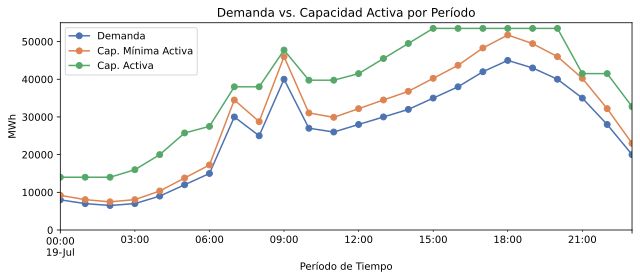

In [20]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

sns.set_palette(sns.color_palette("deep"))

plt.figure(figsize=(9, 4))
results_summary.plot.line(ax=plt.gca(), marker='o')
plt.xlabel("Período de Tiempo")
plt.ylabel("MWh")
plt.title("Demanda vs. Capacidad Activa por Período")
plt.ylim([0, 55000])
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

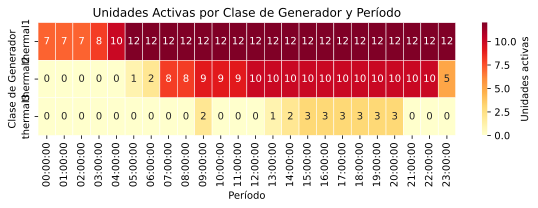

In [21]:
# ── Heatmap: generadores activos por clase y período ────────────────────────
active_matrix = pd.DataFrame(
    index=GENERATORS,
    columns=[str(t.time()) for t in TIME_PERIODS],
    data=[
        [int(round(pe.value(model.num_active[g, i]))) for i in T]
        for g in GENERATORS
    ]
)

plt.figure(figsize=(8, 3))
sns.heatmap(active_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Unidades activas'})
plt.title("Unidades Activas por Clase de Generador y Período")
plt.xlabel("Período")
plt.ylabel("Clase de Generador")
plt.tight_layout()
plt.show()

In [22]:
print(f"\n📊 Estadísticas:")
print(f"   Costo total óptimo : £{costo_total:,.0f}")
print(f"   Clases generadores : {len(GENERATORS)}")
print(f"   Períodos           : {len(T)}")


📊 Estadísticas:
   Costo total óptimo : £1,066,350
   Clases generadores : 3
   Períodos           : 24
